# # 11. Entrenamiento de State Representation Learning (SRL): Autoencoder Temporal
En este notebook entrenamos un Autoencoder basado en LSTMs para aprender representaciones latentes (embeddings) de la serie temporal de Bitcoin. 
La red debe aprender a reconstruir la señal original, obligando al "cuello de botella" (espacio latente) a capturar las características más importantes del mercado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import sys


sys.path.append('../')
from src.srl_models import TemporalAutoencoder

In [ ]:
def create_sliding_windows(data, window_size):
    """
    Transforma un DataFrame en tensores 3D para la red neuronal.
    Entrada: (Filas, Columnas) -> Salida: (Muestras, Ventana, Columnas)
    """
    windows = []
    for i in range(len(data) - window_size):
        # Extraemos un bloque de 'window_size' velas
        window = data.iloc[i : i + window_size].values
        windows.append(window)
    
    # Se retorna un tensor de PyTorch
    return torch.tensor(np.array(windows), dtype=torch.float32)

### Parámetros globales

LATENT_DIM = 16   Es el tamaño del Embedding. Se ha escogido este numero porque los datos originales (1h y 1d) tienen 19 y 18 dimensiones respectivamente, por lo que 16 es una reducción que obliga a eliminar el ruido redundante sin perder información. Además es potencia de 2, que suele ser más eficiente para la gestión de memoria en la GPU

EPOCHS = 50       Son las veces que la IA repasará los datos, al probarlo y llegar a la época 50, la mejora era muy pequeña, por
lo que ofrece un buen equilibrio entre modelo bien entrenado y tiempo de ejecución.

In [ ]:
WINDOW_SIZE = 24  # Miramos las últimas 24 velas (un día entero en el caso de 1h)
LATENT_DIM = 16   # Comprimimos 24 velas en 16 números
HIDDEN_DIM = 64   # Neuronas internas de la LSTM
EPOCHS = 50       # Cuántas veces la IA repasará los datos
BATCH_SIZE = 64   # Cuántas ventanas procesa a la vez 
LEARNING_RATE = 1e-3

# Rutas de fechas (sincronizadas con Notebook 01 y 10)
from_safe = '2021-12-31_00-00-00'
until_safe = '2025-07-31_00-00-00'

### Entrenamiento del Modelo de State Representation Learning (SRL)

El objetivo es entrenar un Autoencoder Temporal que aprenda a comprimir la dinámica del mercado en un espacio latente denso (embedding). El proceso se realiza de forma iterativa para los marcos temporales de 1H y 1D, garantizando que el agente de trading posterior disponga de representaciones optimizadas para ambos horizontes temporales.

In [ ]:
for tf in ["1h", "1d"]:
    print(f"\n--- Iniciando entrenamiento SRL para Marco Temporal: {tf.upper()} ---")
    
    # Carga de datos limpios del Notebook 01
    file_path = f'../data/01-output-BTCUSDT_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    
    # Seleccionamos las columnas que la IA va a "mirar" (log-returns y wavelets)
    # Excluimos 'open', 'high', 'low', 'close' para que aprenda de la señal estacionaria
    features = df.drop(columns=['open', 'high', 'low', 'close', 'tradecount', 'date_ordinal'])
    
    # Preparación de Tensores
    X = create_sliding_windows(features, WINDOW_SIZE)
    dataset = TensorDataset(X)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Inicialización del Modelo
    input_dim = features.shape[1]
    model = TemporalAutoencoder(input_dim, HIDDEN_DIM, LATENT_DIM)
    criterion = nn.MSELoss() # Error Cuadrático Medio
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Bucle de Entrenamiento
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in dataloader:
            inputs = batch[0]
            optimizer.zero_grad()
            
            # Forward: La IA intenta comprimir y reconstruir
            reconstructed, latent = model(inputs)
            loss = criterion(reconstructed, inputs)
            
            # Backward: La IA aprende de su error
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch+1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}], Error de Reconstrucción: {total_loss/len(dataloader):.6f}")

    # Guardado del modelo
    torch.save(model.state_dict(), f'../results/autoencoder_{tf}.pth')
    print(f"Modelo guardado en ../results/autoencoder_{tf}.pth")


--- Iniciando entrenamiento SRL para Marco Temporal: 1H ---
Época [10/50], Error de Reconstrucción: 0.029241
Época [20/50], Error de Reconstrucción: 0.020632
Época [30/50], Error de Reconstrucción: 0.017448
Época [40/50], Error de Reconstrucción: 0.016964
Época [50/50], Error de Reconstrucción: 0.015451
Modelo guardado en ../results/autoencoder_1h.pth

--- Iniciando entrenamiento SRL para Marco Temporal: 1D ---
Época [10/50], Error de Reconstrucción: 0.062252
Época [20/50], Error de Reconstrucción: 0.058088
Época [30/50], Error de Reconstrucción: 0.054522
Época [40/50], Error de Reconstrucción: 0.053085
Época [50/50], Error de Reconstrucción: 0.050382
Modelo guardado en ../results/autoencoder_1d.pth


### Generación y Guardado de Embeddings
Una vez entrenados los modelos, extraemos la representación latente (embedding) 
de cada ventana temporal para crear los nuevos datasets de entrenamiento.

In [ ]:
for tf in ["1h", "1d"]:
    print(f"\n--- Generando CSV de Embeddings para {tf.upper()} ---")
    
    # Recargar los datos originales para tener el índice (fechas)
    file_path = f'../data/01-output-BTCUSDT_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df_original = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    
    # Recrear las ventanas (X) para este timeframe
    features = df_original.drop(columns=['open', 'high', 'low', 'close', 'tradecount', 'date_ordinal'])
    X = create_sliding_windows(features, WINDOW_SIZE)
    
    # Cargar el modelo entrenado y ponerlo en modo evaluación
    input_dim = features.shape[1]
    model = TemporalAutoencoder(input_dim, HIDDEN_DIM, LATENT_DIM)
    model.load_state_dict(torch.load(f'../results/autoencoder_{tf}.pth'))
    model.eval()
    
    # Pasar los datos por el Encoder
    with torch.no_grad():
        embeddings = model.encode(X)
        embeddings_np = embeddings.numpy()

    # Crear el DataFrame final
    # Recordamos que perdemos las primeras WINDOW_SIZE filas por el lookback
    adjusted_index = df_original.index[WINDOW_SIZE:]
    embedding_cols = [f'embedding_{i}' for i in range(LATENT_DIM)]
    
    df_embeddings = pd.DataFrame(embeddings_np, columns=embedding_cols, index=adjusted_index)
    
    # Guardar el resultado
    output_path = f'../data/02-srl-temporal-ae-{tf}-from-{from_safe}-until-{until_safe}.csv'
    df_embeddings.to_csv(output_path)
    
    print(f"Archivo guardado: {output_path}")
    print(f"Dimensiones: {df_embeddings.shape}")


print("\nMuestra de los embeddings de 1H:")
display(df_embeddings.head())


--- Generando CSV de Embeddings para 1H ---
Archivo guardado: ../data/02-srl-temporal-ae-1h-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv
Dimensiones: (30977, 16)

--- Generando CSV de Embeddings para 1D ---
Archivo guardado: ../data/02-srl-temporal-ae-1d-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv
Dimensiones: (1285, 16)

Muestra de los embeddings de 1H:


,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,embedding_11,embedding_12,embedding_13,embedding_14,embedding_15
date,,,,,,,,,,,,,,,,
2022-01-25,0.459987,0.424200,-0.240113,-0.086077,-0.551056,0.254461,0.069703,0.527409,0.310009,0.187644,0.178646,0.170532,0.351494,0.219889,0.641894,0.379417
2022-01-26,0.353953,0.179947,-0.438291,-0.193814,-0.692277,0.321625,0.122544,0.393451,0.440109,0.292476,0.039200,0.315208,0.468884,0.330354,0.654420,0.171404
2022-01-27,0.246478,-0.014891,-0.588305,-0.122948,-0.749514,0.375224,0.110078,0.193398,0.586464,0.368432,-0.137888,0.392504,0.504539,0.432704,0.608382,0.007134
2022-01-28,0.108985,-0.154457,-0.672090,0.013488,-0.758697,0.356485,0.046002,0.011111,0.675494,0.435282,-0.220999,0.386295,0.497992,0.495090,0.540979,-0.113325
2022-01-29,-0.008466,-0.291887,-0.702130,0.167326,-0.755724,0.321023,-0.046445,-0.175583,0.718087,0.490023,-0.273425,0.347004,0.464602,0.513349,0.467890,-0.176175


### Prueba de Ajuste: Señal Real vs. Señal Reconstruida
Recargamos las dimensiones específicas de 1H para evitar el error de mismatch.

Dimensiones detectadas para 1H: 19


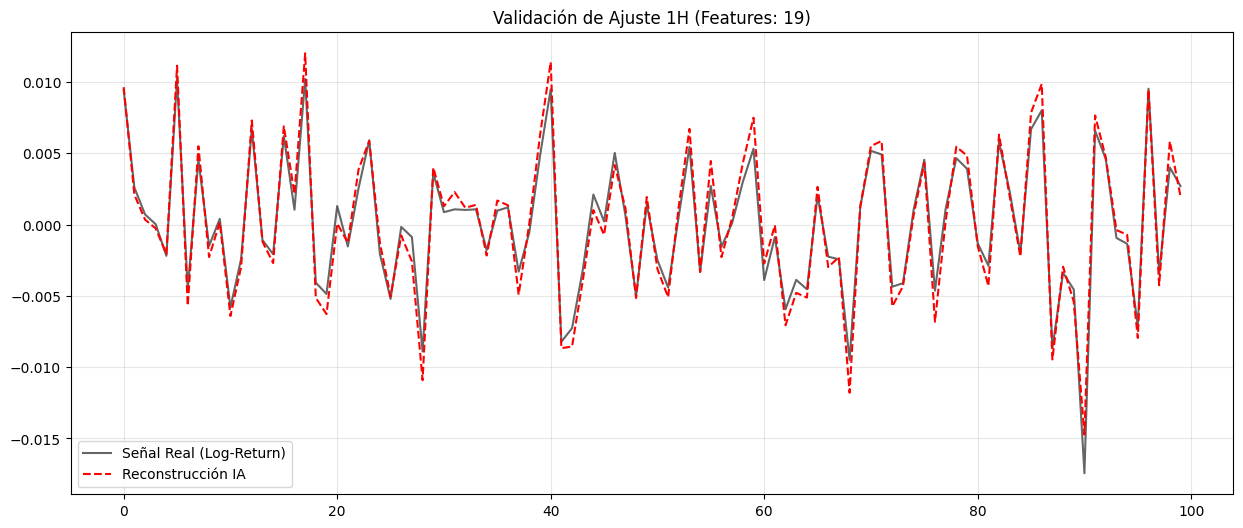

In [ ]:
# Cargamos de nuevo los datos de 1H para obtener sus dimensiones exactas
file_path_1h = f'../data/01-output-BTCUSDT_1h-from-{from_safe}-until-{until_safe}-log-return.csv'
df_1h = pd.read_csv(file_path_1h, parse_dates=['date'], index_col='date')
features_1h = df_1h.drop(columns=['open', 'high', 'low', 'close', 'tradecount', 'date_ordinal'])

# Definimos las dimensiones reales de 1H (deberían ser 19 según tu error)
input_dim_1h = features_1h.shape[1] 
print(f"Dimensiones detectadas para 1H: {input_dim_1h}")

# Inicializamos el modelo con la dimensión correcta
model_1h = TemporalAutoencoder(input_dim_1h, HIDDEN_DIM, LATENT_DIM)
model_1h.load_state_dict(torch.load('../results/autoencoder_1h.pth'))
model_1h.eval()

# Preparamos las ventanas para la visualización
X_1h = create_sliding_windows(features_1h, WINDOW_SIZE)

with torch.no_grad():
    # Reconstruimos una muestra (ej. las primeras 200 ventanas)
    sample_input = X_1h[:200]
    reconstructed, _ = model_1h(sample_input)

# Comparamos la reconstrucción de la primera característica
plt.figure(figsize=(15, 6))
# Usamos el último paso de tiempo de la ventana [-1] y la primera característica [0]
plt.plot(sample_input[:100, -1, 0], label='Señal Real (Log-Return)', color='black', alpha=0.6)
plt.plot(reconstructed[:100, -1, 0], label='Reconstrucción IA', color='red', linestyle='--')
plt.title(f'Validación de Ajuste 1H (Features: {input_dim_1h})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Como vemos, La capacidad del Autoencoder para replicar los movimientos de la señal original indica que el espacio latente de 16 dimensiones ($s_t$) ha capturado con éxito la varianza y la estructura de los datos.

Se observa que la reconstrucción (línea roja) tiende a ignorar micro-fluctuaciones extremas o "picos de ruido", manteniendo la trayectoria fundamental. Este efecto de suavizado es una propiedad intrínseca del "cuello de botella" de la red, lo que proporciona al agente de trading una representación más limpia y menos errática.